# Section 5.5, Figure 1

Compares ordinary double-scoring edge-popup training with an extra score-capacity variant on FashionMNIST.

## Run Notes
- Run the notebook from top to bottom.
- Downloads FashionMNIST on first run.
- The extra score capacity changes the score tensor width while keeping the realized weights fixed.
- Random sampling is intentionally exposed in the experiment cells so readers can vary it.

## Setup

In [ ]:
import math

import torch
import torch.autograd as autograd
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor

# Prefer a GPU in Colab, fall back to Apple MPS when available, and use CPU otherwise.
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

def signed_kaiming_constant_(
    tensor,
    a=0,
    mode="fan_in",
    nonlinearity="relu",
    k=0.5,
    sparsity=0,
):
    """Initialize frozen weights with signed Kaiming-style uniform samples."""
    fan = nn.init._calculate_correct_fan(tensor, mode)
    gain = nn.init.calculate_gain(nonlinearity, a)
    std = gain / math.sqrt(fan)

    # The active subnetwork keeps a k-fraction of weights, so rescale by 1/sqrt(k).
    if k != 0:
        std *= 1 / math.sqrt(k)

    with torch.no_grad():
        tensor.uniform_(-std, std)
        if sparsity > 0:
            keep_mask = (torch.rand_like(tensor) > sparsity).float()
            tensor *= keep_mask
        return tensor

class GetSubnet(autograd.Function):
    """Straight-through top-k mask used by edge-popup."""

    @staticmethod
    def forward(ctx, scores, k=0.5):
        # Convert scores to a binary mask by keeping the largest k-fraction.
        out = scores.clone()
        _, idx = scores.flatten().sort()
        cutoff = int((1 - k) * scores.numel())
        flat_out = out.flatten()
        flat_out[idx[:cutoff]] = 0
        flat_out[idx[cutoff:]] = 1
        return out

    @staticmethod
    def backward(ctx, grad):
        # Straight-through estimator: pass score gradients through unchanged.
        return grad, None

class LinearSubnet(nn.Linear):
    """Linear layer with frozen weights and trainable scores that choose the mask."""

    def __init__(
        self,
        in_features,
        out_features,
        init=signed_kaiming_constant_,
        k=0.5,
        extra_capacity=0,
        double=True,
        **kwargs,
    ):
        super().__init__(in_features, out_features, **kwargs)
        multiplier = 2 if double else 1
        self.k = k

        # Scores can be wider than the weight matrix; only the realized weight slice is used.
        self.scores = nn.Parameter(
            torch.randn(out_features, multiplier * in_features + extra_capacity)
        )
        init(self.weight)
        self.weight.requires_grad_(False)

        if self.bias is not None:
            self.bias_scores = nn.Parameter(
                torch.randn(multiplier + extra_capacity, out_features)
            )
            self.bias.requires_grad_(False)

    def forward(self, x):
        weight_mask = GetSubnet.apply(self.scores.abs(), self.k)
        weight = self.weight * weight_mask[:, : self.weight.shape[-1]]

        if self.bias is None:
            return F.linear(x, weight)

        bias_mask = GetSubnet.apply(self.bias_scores.abs(), self.k)
        bias = self.bias * bias_mask[1, : self.bias.shape[-1]]
        return F.linear(x, weight, bias)


class Network(nn.Module):
    """Small MLP assembled from masked LinearSubnet layers."""

    def __init__(
        self,
        layer_sizes,
        init=signed_kaiming_constant_,
        bias=True,
        double=True,
        extra_capacity=0,
    ):
        super().__init__()
        self.flatten = nn.Flatten()
        self.layers = nn.Sequential(
            *[
                block
                for layer in layer_sizes
                for block in [
                    LinearSubnet(
                        layer[0],
                        layer[1],
                        init=init,
                        bias=bias,
                        double=double,
                        extra_capacity=extra_capacity,
                    ),
                    nn.ReLU(),
                ]
            ][:-1]
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.layers(x)

Using cuda device


## Experiment and Figure

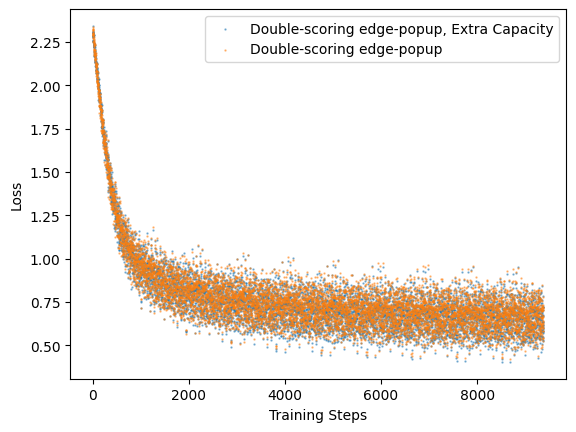

In [ ]:
# Experiment outline:
# 1. Train a standard double-scoring model and an extra-score-capacity variant.
# 2. Evaluate both models during training on FashionMNIST.
# 3. Plot the two loss trajectories.

epochs = 10
batch_size = 64
layer_sizes=[[28*28,128],[128,10]]
extra_capacity=512

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
train_dataloader = DataLoader(training_data, batch_size=batch_size)
model_extra_capacity = Network(layer_sizes, extra_capacity=extra_capacity)
model_extra_capacity.to(device)
optimizer_extra_capacity = torch.optim.Adam(model_extra_capacity.parameters())
model_double_scoring = Network(layer_sizes)
model_double_scoring.to(device)
optimizer_double_scoring = torch.optim.Adam(model_double_scoring.parameters())
loss_fn = nn.CrossEntropyLoss()
losses_double_scoring = []
losses_extra_capacity = []
for t in range(epochs):
    model_extra_capacity.train()
    model_double_scoring.train()
    for (X, y) in train_dataloader:
        X,y = X.to(device), y.to(device)
        optimizer_extra_capacity.zero_grad()
        optimizer_double_scoring.zero_grad()
        pred_extra_capacity = model_extra_capacity(X)
        pred_double_scoring = model_double_scoring(X)
        loss_extra_capacity = loss_fn(pred_extra_capacity, y)
        loss_double_scoring = loss_fn(pred_double_scoring, y)
        losses_extra_capacity.append(loss_extra_capacity.item())
        losses_double_scoring.append(loss_double_scoring.item())
        loss_extra_capacity.backward()
        loss_double_scoring.backward()
        optimizer_extra_capacity.step()
        optimizer_double_scoring.step()
plt.scatter(
    range(len(losses_extra_capacity)),
    losses_extra_capacity,
    label="Double-scoring edge-popup, Extra Capacity",
    s=0.5,
    alpha=0.5,
)
plt.scatter([i for i in range(len(losses_double_scoring))],losses_double_scoring, label="Double-scoring edge-popup", s=0.5, alpha=0.5)
plt.ylabel("Loss")
plt.xlabel("Training Steps")
plt.legend()